In [62]:
# import libraries

# 1. to handle the data
import pandas as pd
import numpy as np

# 2. To Viusalize the data
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# from yellowbrick.cluster import KElbowVisualizer
from matplotlib.colors import ListedColormap

# 3. To preprocess the data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer

# 4. import Iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 5. Machine Learning
from sklearn.model_selection import train_test_split,GridSearchCV, cross_val_score

# 6. For Classification task.
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,ExtraTreesClassifier,RandomForestRegressor
# from xgboost import XGBClassifier

# 7. Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 8. Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [63]:
import pandas as pd

# Load the Excel file into a DataFrame
df = pd.read_excel(r"D:\MLDP Project\data\heart_disease_clean.xlsx")

# Check the shape and first few rows
print(df.shape)
print(df.head())


(299, 14)
   age_years sex_male_female  chest_pain_type  resting_bp_mmHg  \
0         63            Male   typical angina              145   
1         67            Male     asymptomatic              160   
2         67            Male     asymptomatic              120   
3         37            Male      non-anginal              130   
4         41          Female  atypical angina              130   

   serum_cholesterol_mgdl  fasting_blood_sugar_gt120 resting_ecg_result  \
0                     233                       True     lv hypertrophy   
1                     286                      False     lv hypertrophy   
2                     229                      False     lv hypertrophy   
3                     250                      False             normal   
4                     204                      False     lv hypertrophy   

   thalch  exercise_induced_angina  st_depression_exercise  \
0     150                    False                     2.3   
1     108         

In [64]:
# Checking for missing values
df.isnull().sum()


age_years                    0
sex_male_female              0
chest_pain_type              0
resting_bp_mmHg              0
serum_cholesterol_mgdl       0
fasting_blood_sugar_gt120    0
resting_ecg_result           0
thalch                       0
exercise_induced_angina      0
st_depression_exercise       0
st_slope_peak_exercise       0
num_major_vessels            0
thal_defect_type             0
severity_label               0
dtype: int64

In [65]:
df

,age_years,sex_male_female,chest_pain_type,resting_bp_mmHg,serum_cholesterol_mgdl,fasting_blood_sugar_gt120,resting_ecg_result,thalch,exercise_induced_angina,st_depression_exercise,st_slope_peak_exercise,num_major_vessels,thal_defect_type,severity_label
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,0,fixed defect,Normal
1,67,Male,asymptomatic,160,286,False,lv hypertrophy,108,True,1.5,flat,3,normal,Very Severe
2,67,Male,asymptomatic,120,229,False,lv hypertrophy,129,True,2.6,flat,2,reversable defect,Very Severe
3,37,Male,non-anginal,130,250,False,normal,187,False,3.5,downsloping,0,normal,Normal
4,41,Female,atypical angina,130,204,False,lv hypertrophy,172,False,1.4,upsloping,0,normal,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,68,Male,asymptomatic,144,193,True,normal,141,False,3.4,flat,2,reversable defect,Very Severe
295,57,Male,asymptomatic,130,131,False,normal,115,True,1.2,flat,1,reversable defect,Very Severe
296,57,Female,atypical angina,130,236,False,lv hypertrophy,174,False,0.0,flat,1,normal,Very Severe
297,47,Male,asymptomatic,150,226,False,normal,98,True,1.5,flat,0,reversable defect,Very Severe


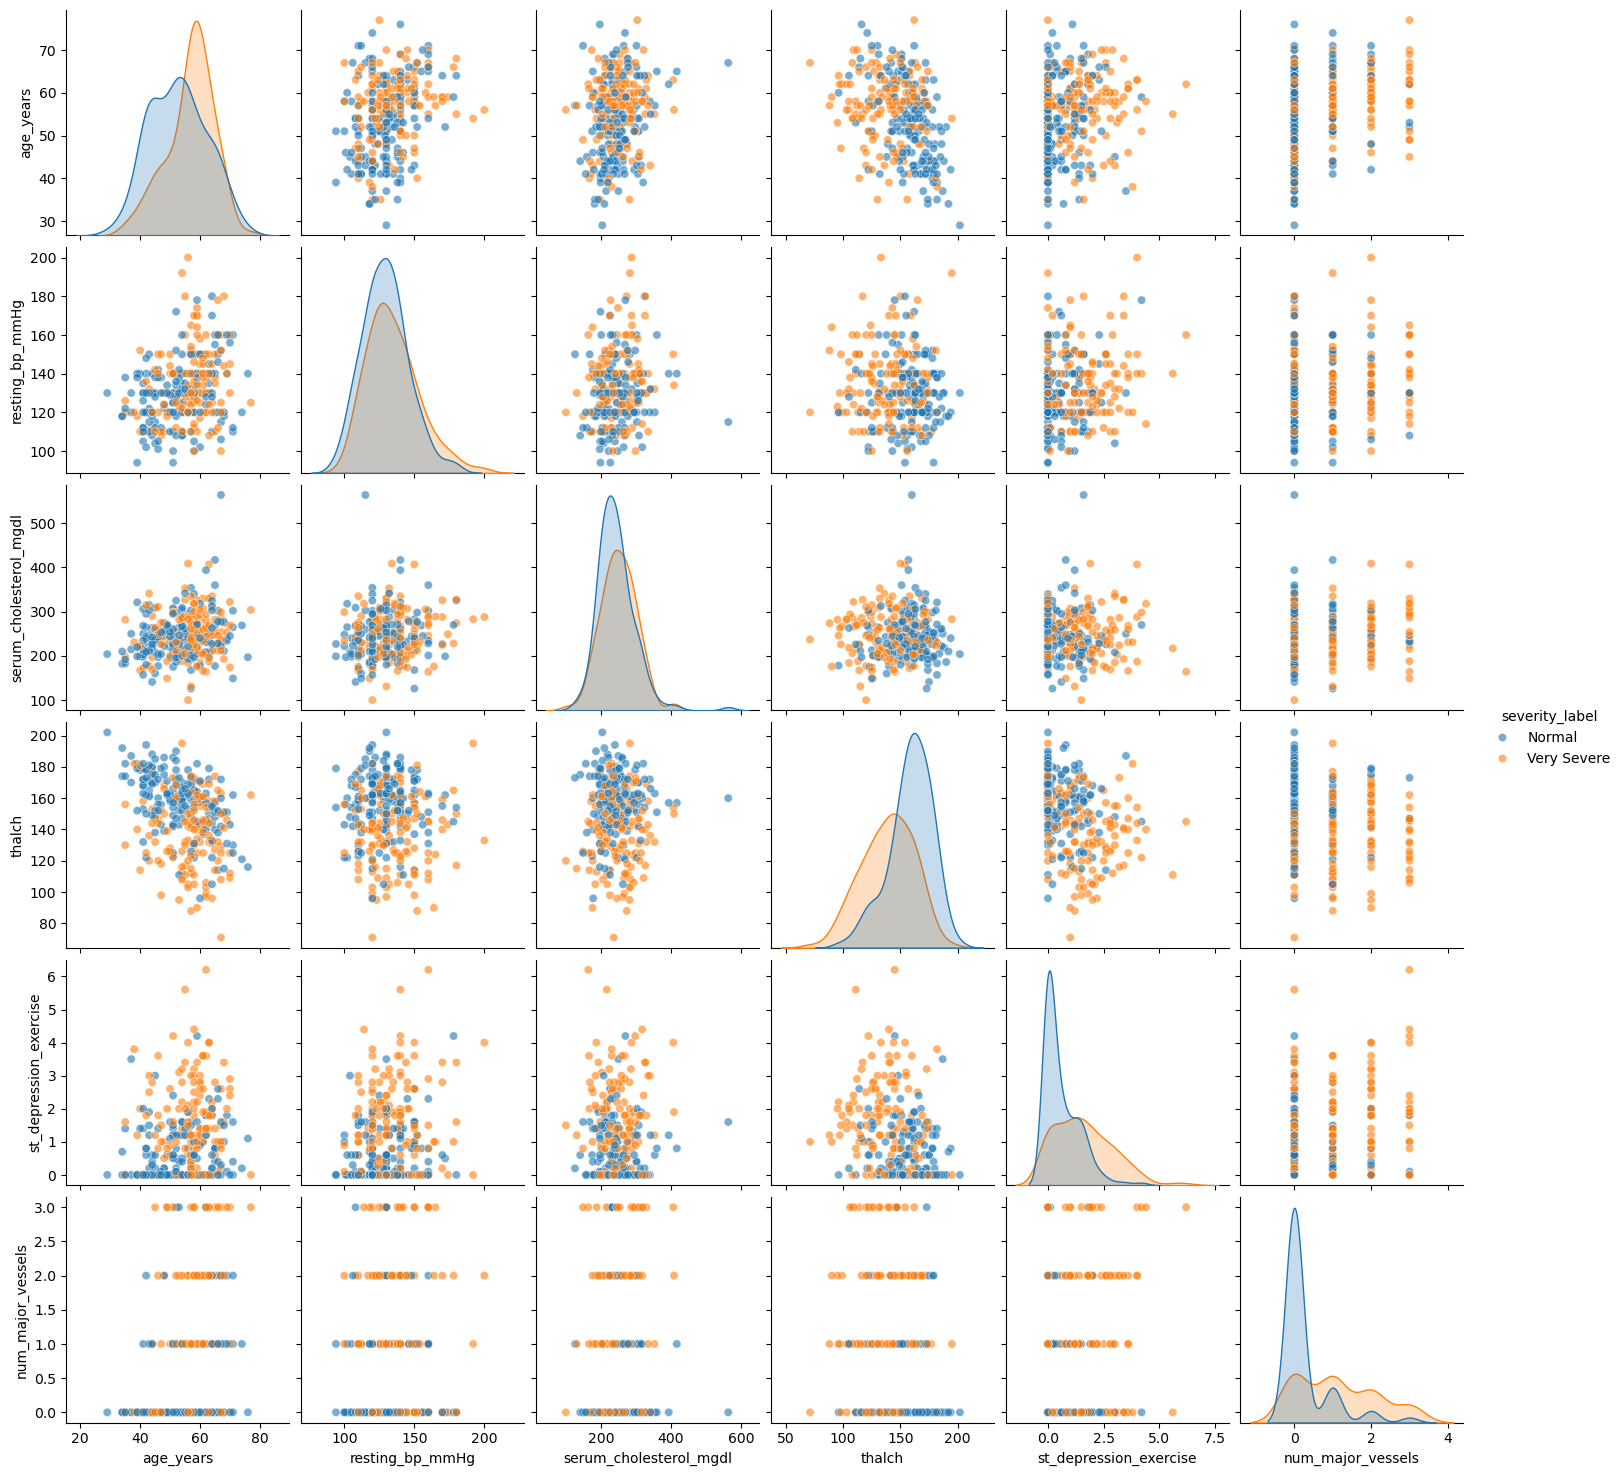

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming my DataFrame is called df

# Select only numeric columns for pairplot
numeric_cols = [
    'age_years',
    'resting_bp_mmHg',
    'serum_cholesterol_mgdl',
    'thalch',
    'st_depression_exercise',
    'num_major_vessels'
]

# Create pairplot, color by target variable
sns.pairplot(df[numeric_cols + ['severity_label']], 
             hue='severity_label', 
             diag_kind='kde', 
             plot_kws={'alpha':0.6})

plt.show()


In [67]:
# df = df.drop(columns=["severity_label"])


In [68]:
df

,age_years,sex_male_female,chest_pain_type,resting_bp_mmHg,serum_cholesterol_mgdl,fasting_blood_sugar_gt120,resting_ecg_result,thalch,exercise_induced_angina,st_depression_exercise,st_slope_peak_exercise,num_major_vessels,thal_defect_type,severity_label
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,0,fixed defect,Normal
1,67,Male,asymptomatic,160,286,False,lv hypertrophy,108,True,1.5,flat,3,normal,Very Severe
2,67,Male,asymptomatic,120,229,False,lv hypertrophy,129,True,2.6,flat,2,reversable defect,Very Severe
3,37,Male,non-anginal,130,250,False,normal,187,False,3.5,downsloping,0,normal,Normal
4,41,Female,atypical angina,130,204,False,lv hypertrophy,172,False,1.4,upsloping,0,normal,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,68,Male,asymptomatic,144,193,True,normal,141,False,3.4,flat,2,reversable defect,Very Severe
295,57,Male,asymptomatic,130,131,False,normal,115,True,1.2,flat,1,reversable defect,Very Severe
296,57,Female,atypical angina,130,236,False,lv hypertrophy,174,False,0.0,flat,1,normal,Very Severe
297,47,Male,asymptomatic,150,226,False,normal,98,True,1.5,flat,0,reversable defect,Very Severe


In [69]:
#Outlier Count
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()
print(outliers)


age_years                  0
resting_bp_mmHg            9
serum_cholesterol_mgdl     6
thalch                     1
st_depression_exercise     5
num_major_vessels         20
dtype: int64


In [70]:
#Age years has no outliers (Clean Distribution)
#resting_bp_mmHg has 9 Outliers (Moderate Distribution)
#serum_cholesterol_mgdl has 6 Outliers (Moderate Distribution)
#thalch has 1 outlier (Minimal Distribution)
#st_depression_exercise has 5 outliers (Moderate Distribution)
#num_major_vessels has 20 outliers (High Distribution)

<Axes: xlabel='num_major_vessels', ylabel='count'>

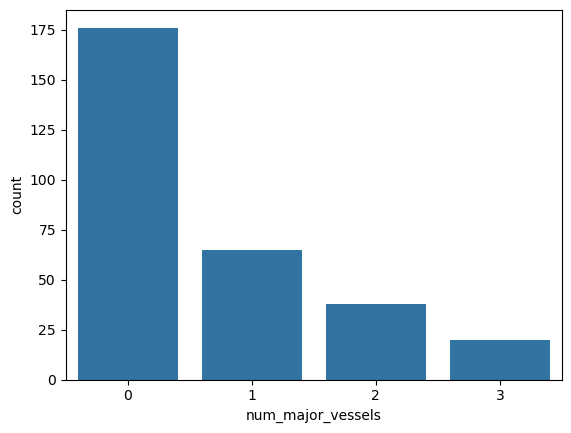

In [71]:
# shows countplot for num_major_vessels

import seaborn as sns
sns.countplot(x='num_major_vessels', data=df)


In [72]:
import numpy as np
import pandas as pd

#Removal of major Outliers in 'num_major_vessels' column

# Step 1: Calculate Q1, Q3, and IQR for the column
Q1 = df['num_major_vessels'].quantile(0.25)
Q3 = df['num_major_vessels'].quantile(0.75)
IQR = Q3 - Q1

# Step 2: Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 3a: Remove outliers (rows outside bounds)
df_clean = df[(df['num_major_vessels'] >= lower_bound) & (df['num_major_vessels'] <= upper_bound)]

# Step 3b: Cap values at bounds (Winsorization)
df['num_major_vessels'] = np.clip(df['num_major_vessels'], lower_bound, upper_bound)

# Step 3c: Create an outlier flag column (True if outlier, False otherwise)
df['num_major_vessels_outlier'] = ~((df['num_major_vessels'] >= lower_bound) & (df['num_major_vessels'] <= upper_bound))


In [73]:
#Outlier Count
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()
print(outliers)


age_years                 0
resting_bp_mmHg           9
serum_cholesterol_mgdl    6
thalch                    1
st_depression_exercise    5
num_major_vessels         0
dtype: int64


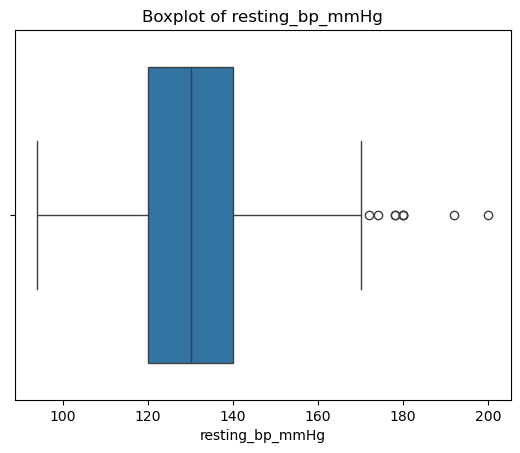

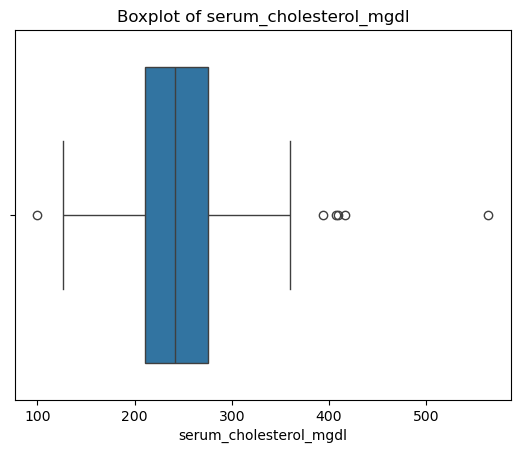

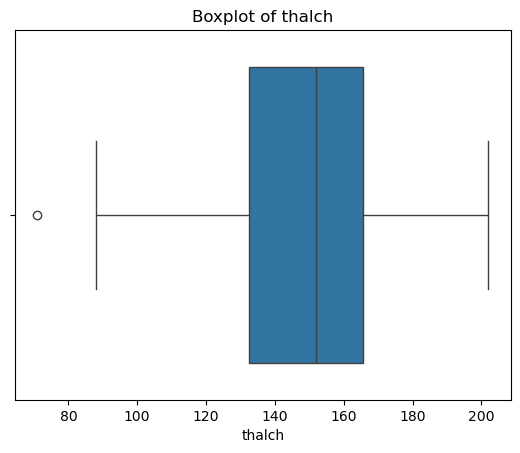

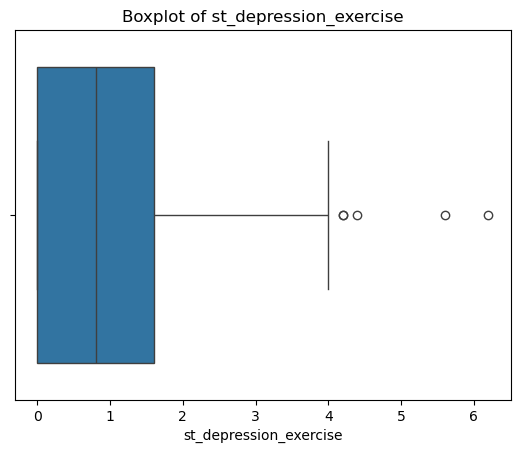

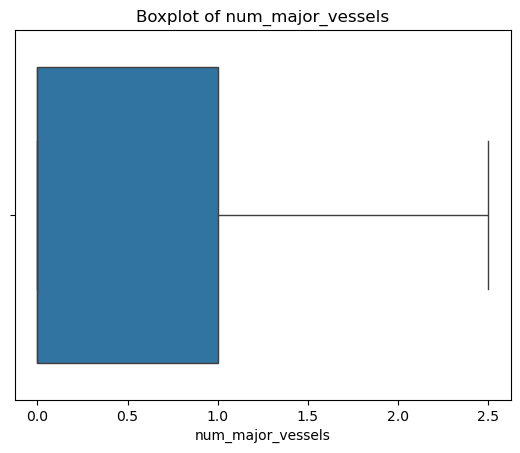

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['resting_bp_mmHg', 'serum_cholesterol_mgdl', 'thalch', 'st_depression_exercise', 'num_major_vessels']:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [75]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Defining target column
col_y = 'severity_label'
y = df[col_y]

# Drop target column only (no extra irrelevant columns in my dataset)
X = df.drop(col_y, axis=1)

# One-Hot Encoding for categorical variables
X = pd.get_dummies(X, drop_first=True)

# Split data into train and test sets
test_size = 0.3
random_state = 2025
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=random_state
)


In [76]:
#Logistic Regression Model (Model 1)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix




In [77]:
# Train Logistic Regression
logr = LogisticRegression(max_iter=1000, random_state=42)
logr.fit(X_train, y_train)

# Predictions
y_pred_logr = logr.predict(X_test)

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logr))
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred_logr))
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred_logr))


Logistic Regression Accuracy: 0.8222222222222222


In [78]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Evaluate
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred_dt))
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.7666666666666667


In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred_rf))
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.7777777777777778


In [80]:
#Logistic Regression is best used because it has the highest accuracy among all models tested.

In [81]:
#Further Tuning and Evaluation is done in next cell using optuna

In [82]:
import optuna
import numpy as np
from time import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Track runtime
start = time()
speed = {}

def objective(trial):
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Auto-detect categorical and numeric columns
    categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # Preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
            ('num', 'passthrough', numeric_features)
        ]
    )

    # Hyperparameter search space for Logistic Regression
    solver = trial.suggest_categorical("solver", ["liblinear", "saga"])
    penalty = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet"])
    C = trial.suggest_float("C", 0.01, 10.0, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)

    # Filter invalid combos
    if solver == "liblinear" and penalty not in ["l1", "l2"]:
        raise optuna.TrialPruned()
    if solver != "saga" and penalty == "elasticnet":
        raise optuna.TrialPruned()
    if penalty != "elasticnet":
        l1_ratio = None

    # Build pipeline
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            penalty=penalty,
            C=C,
            solver=solver,
            l1_ratio=l1_ratio,
            max_iter=1000,
            random_state=42
        ))
    ])

    # Train and evaluate
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    return acc

# Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

# Record runtime
speed['LogisticRegression'] = np.round(time() - start, 3)

# Print best parameters
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {trial.value}")
print("  Parameters:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

print(f"Run time: {speed['LogisticRegression']}s")

# Evaluate best model on train/test
best_params = trial.params
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(**best_params, max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)

# Metrics
acc_train = accuracy_score(y_train, model.predict(X_train))
acc_test = accuracy_score(y_test, model.predict(X_test))

print(f"Accuracy train: {acc_train:.4f}, Accuracy test: {acc_test:.4f}")


[I 2026-01-21 11:57:35,388] A new study created in memory with name: no-name-30413e4e-7f3f-4d89-b7a3-15daca8f6fe6
[I 2026-01-21 11:57:35,392] Trial 0 pruned. 
[I 2026-01-21 11:57:35,495] Trial 1 finished with value: 0.7833333333333333 and parameters: {'solver': 'saga', 'penalty': 'elasticnet', 'C': 9.430252335389122, 'l1_ratio': 0.016621722110649273}. Best is trial 1 with value: 0.7833333333333333.
[I 2026-01-21 11:57:35,576] Trial 2 finished with value: 0.7833333333333333 and parameters: {'solver': 'saga', 'penalty': 'l2', 'C': 0.38141471860927895, 'l1_ratio': 0.5463043639917029}. Best is trial 1 with value: 0.7833333333333333.
[I 2026-01-21 11:57:35,598] Trial 3 finished with value: 0.8666666666666667 and parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.6068953962283691, 'l1_ratio': 0.34914565803241837}. Best is trial 3 with value: 0.8666666666666667.
[I 2026-01-21 11:57:35,701] Trial 4 finished with value: 0.7666666666666667 and parameters: {'solver': 'saga', 'penalty': '

Best trial:
  Accuracy: 0.9166666666666666
  Parameters:
    solver: liblinear
    penalty: l1
    C: 5.3518352563614675
    l1_ratio: 0.1637772959333027
Run time: 0.844s
Accuracy train: 0.8661, Accuracy test: 0.9167


In [83]:
#Using Coefficients to determine Feature Importance
coef = model.named_steps['classifier'].coef_[0]
features = model.named_steps['preprocessor'].get_feature_names_out()
importance = pd.DataFrame({'Feature': features, 'Coefficient': coef}).sort_values(by='Coefficient', ascending=False)
print(importance.head(15))


                                         Feature  Coefficient
30                        num__num_major_vessels     1.359431
29                   num__st_depression_exercise     0.384575
24  cat__thal_defect_type_reversable defect_True     0.262935
3              cat__exercise_induced_angina_True     0.261598
9         cat__chest_pain_type_non-anginal_False     0.045189
11     cat__chest_pain_type_typical angina_False     0.025898
26                          num__resting_bp_mmHg     0.024141
13          cat__resting_ecg_result_normal_False     0.023196
18         cat__st_slope_peak_exercise_flat_True     0.022926
6                 cat__sex_male_female_Male_True     0.021134
19   cat__st_slope_peak_exercise_upsloping_False     0.018770
7     cat__chest_pain_type_atypical angina_False     0.015303
0           cat__fasting_blood_sugar_gt120_False     0.010731
21            cat__thal_defect_type_normal_False     0.004934
27                   num__serum_cholesterol_mgdl     0.004034


# - Dominant predictor: num_major_vessels (structural heart disease marker).
# - Strong functional markers: st_depression_exercise, exercise_induced_angina, thal_defect_type.
# - Demographics (sex, age, cholesterol, blood sugar): weaker predictors in this model.
# - ECG-related features: contribute but with smaller coefficients.

# 👉 In practice:
# - Logistic regression coefficients give direction and relative importance, but not direct probabilities.
# - To make them clinically interpretable, you can convert coefficients into odds ratios:
# \mathrm{Odds\  Ratio}=e^{\mathrm{coefficient}}
# - For example, num_major_vessels (1.359) → e^{1.359}\approx 3.89.
# Meaning: each additional blocked vessel multiplies severity odds by ~3.9.
# Would you like me to transform all these coefficients into odds ratios so you can see the clinical impact more clearly?

In [ ]:
import os
import joblib

# Make sure the folder exists
os.makedirs("Models", exist_ok=True)

# Save model to file
joblib.dump(model, "Models/trained_HD_model.pkl")
print("Model saved to Models/trained_HD_model.pkl  ")


Model saved to Models/trained_HD_model.pkl  
